# Hyperparameter Distributions

Plots the distributions of selected `max_val` and `alpha` hyperparameters
across datasets, showing which values CDVM's grid search picks most often.

**Input:** `data/attr_selected_vals/*.npy`  
**Output:** `output/` (hyperparameter distribution plots)

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

## Helper functions

In [2]:
def load_dataset_prob(dataset_name):
    pth = "data/attr_selected_vals/"
    files = os.listdir(pth)
    max_vals = []
    alphas = []
    sizes = []
    num_models = []
    probs = []
    
    for file_name in files:
        
        if file_name.startswith(dataset_name):
            data = np.load(pth + file_name, allow_pickle=True).item()
            max_vals.append(data['max_val'])
            alphas.append(data['alpha'])
            
            num_models.append(file_name.split('-')[-2])
            probs.append(file_name.split('-')[-3])
            sizes.append(file_name.split('-')[-4])
            
    return pd.DataFrame({'max_val': np.array(max_vals), 
                         'alpha': np.array(alphas),
                         'size': np.array(sizes).astype(int),
                         'num_models': np.array(num_models).astype(int),
                         'prob': np.array(probs).astype(float)})

In [3]:
def plot_overall_stats(
        dataset_names=["cifar10-embeddings", "imdb-embeddings", "bbc-embeddings", "nomao", "pol", "adult"]):
    """Plot overall distributions of 'max_val' and 'alpha'."""
    import matplotlib.pyplot as plt
    import seaborn as sns

    dfs = [load_dataset_prob(dataset_name) for dataset_name in dataset_names]
    df = pd.concat(dfs, keys=dataset_names, names=['dataset', 'index']).reset_index(level='dataset')

    # drop rows wehre size is not between 50 and 300
    df = df[(df['size'] >= 50) & (df['size'] <= 300)]

    fig, axes = plt.subplots(1, 1, figsize=(5, 5))
    axes.set_facecolor('white')

    df["size"] = df["size"] / 1000
    plt.rcParams.update({'font.size': 16})

    sns.boxplot(data=df, x='size', y='max_val', ax=axes)
    axes.set_xlabel('size', fontsize=18)
    axes.set_ylabel('kappa', fontsize=18)
    axes.set_title('(c) Distribution of kappa', fontsize=20)
    axes.tick_params(axis='x', rotation=45)
    axes.set_box_aspect(1)
    axes.spines['bottom'].set_color('black')
    axes.spines['top'].set_color('black')
    axes.spines['left'].set_color('black')
    axes.spines['right'].set_color('black')

    plt.tight_layout()
    plt.savefig("output/maxval_distribution.pdf")
    plt.show()

    fig, axes = plt.subplots(1, 1, figsize=(5, 5))
    axes.set_facecolor('white')

    sns.boxplot(data=df, x='size', y='alpha', ax=axes)
    axes.tick_params(axis='x', rotation=45)
    axes.set_box_aspect(1)
    axes.spines['bottom'].set_color('black')
    axes.spines['top'].set_color('black')
    axes.spines['left'].set_color('black')
    axes.spines['right'].set_color('black')

    plt.tight_layout()
    plt.savefig("output/alpha_distributions.pdf")
    plt.show()


## Generate figures

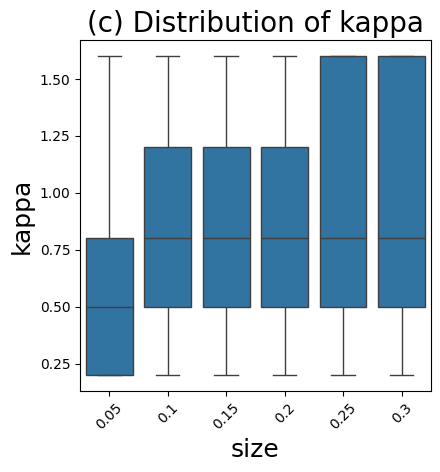

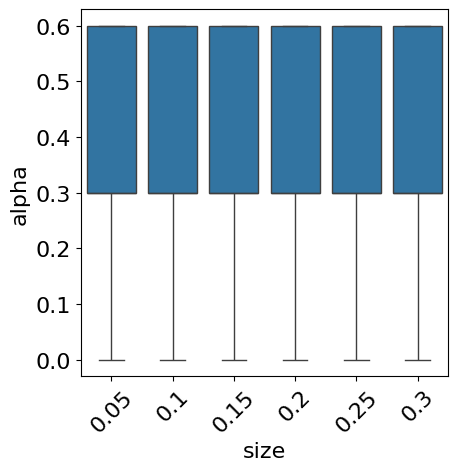

In [4]:
plot_overall_stats()

In [5]:
def plot_stats_for_dataset(dataset_name):
    """Plot distributions of 'max_val' and 'alpha' for a given dataset:

    - Over the entire dataset
    - Per size

    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Load dataset
    df = load_dataset_prob(dataset_name)

    # Create figure with two columns
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # Plot overall distributions
    sns.histplot(data=df, x='max_val', ax=axes[0])
    axes[0].set_title('Distribution of kappa')

    sns.histplot(data=df, x='alpha', ax=axes[1])
    axes[1].set_title('Distribution of alpha')


    # Plot distributions by size
    sns.boxplot(data=df, x='size', y='max_val', ax=axes[2])
    axes[2].set_title('Max_val by size')
    axes[3].tick_params(axis='x', rotation=45)

    sns.boxplot(data=df, x='size', y='alpha', ax=axes[3])
    axes[3].set_title('Alpha by size')
    axes[3].tick_params(axis='x', rotation=45)

    plt.suptitle(dataset_name)
    plt.tight_layout()
    plt.show()


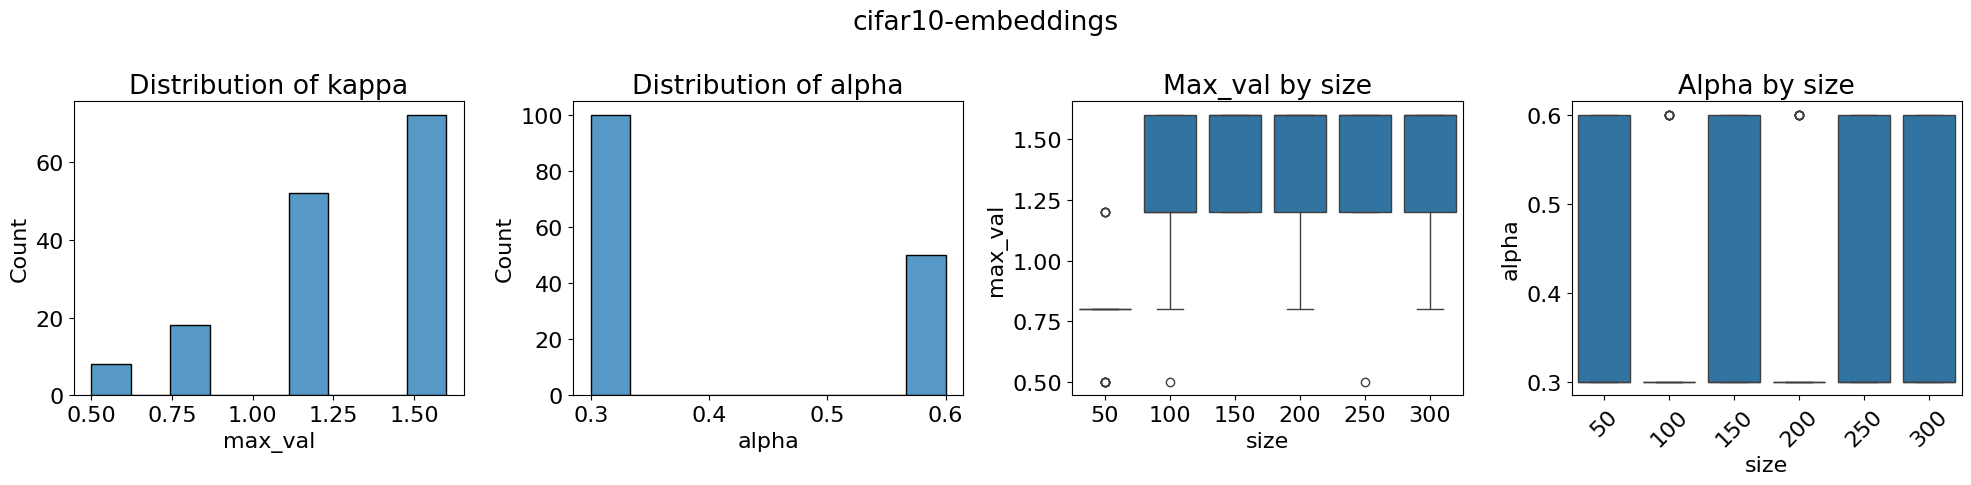

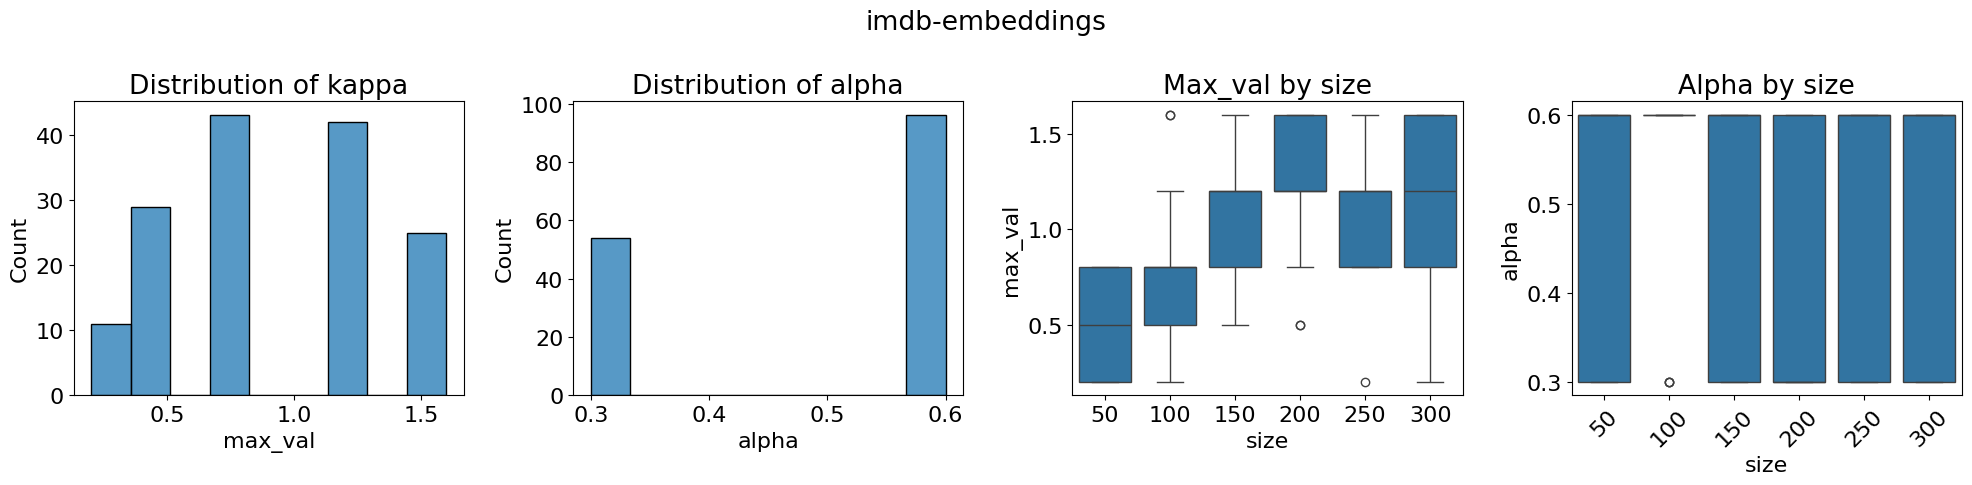

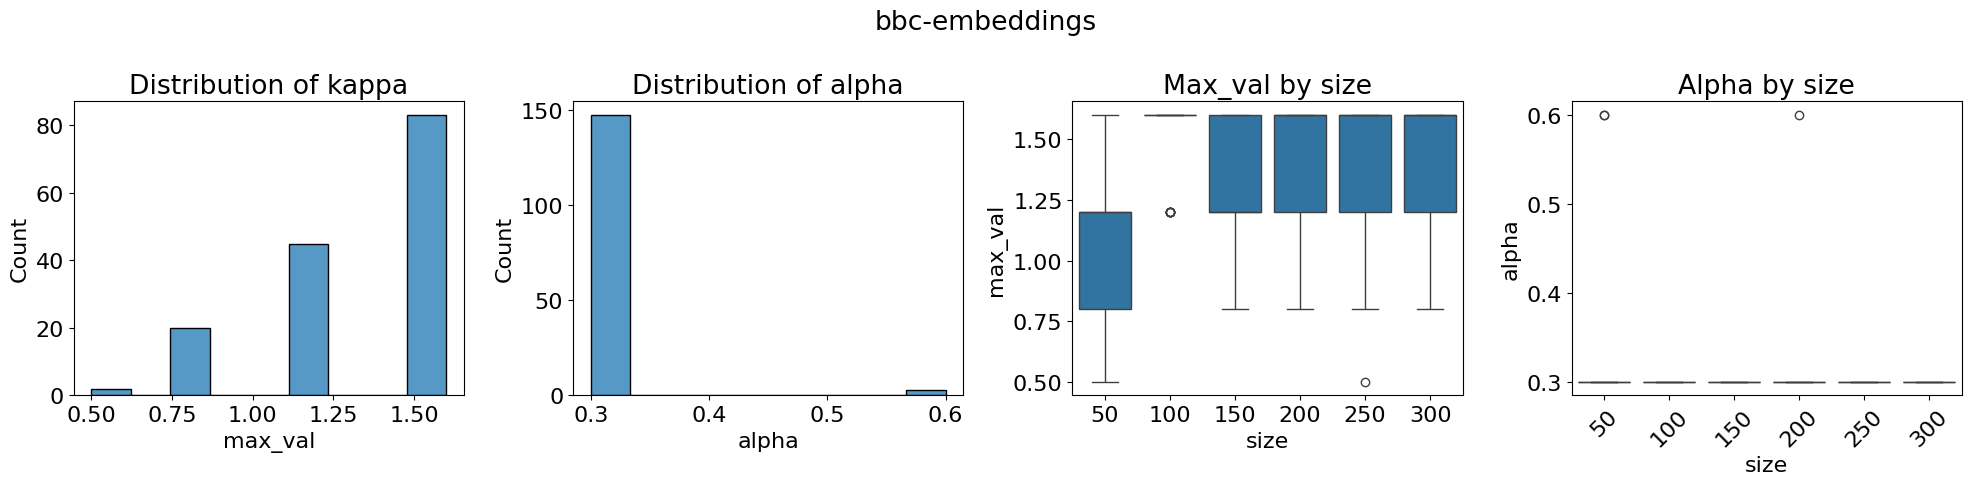

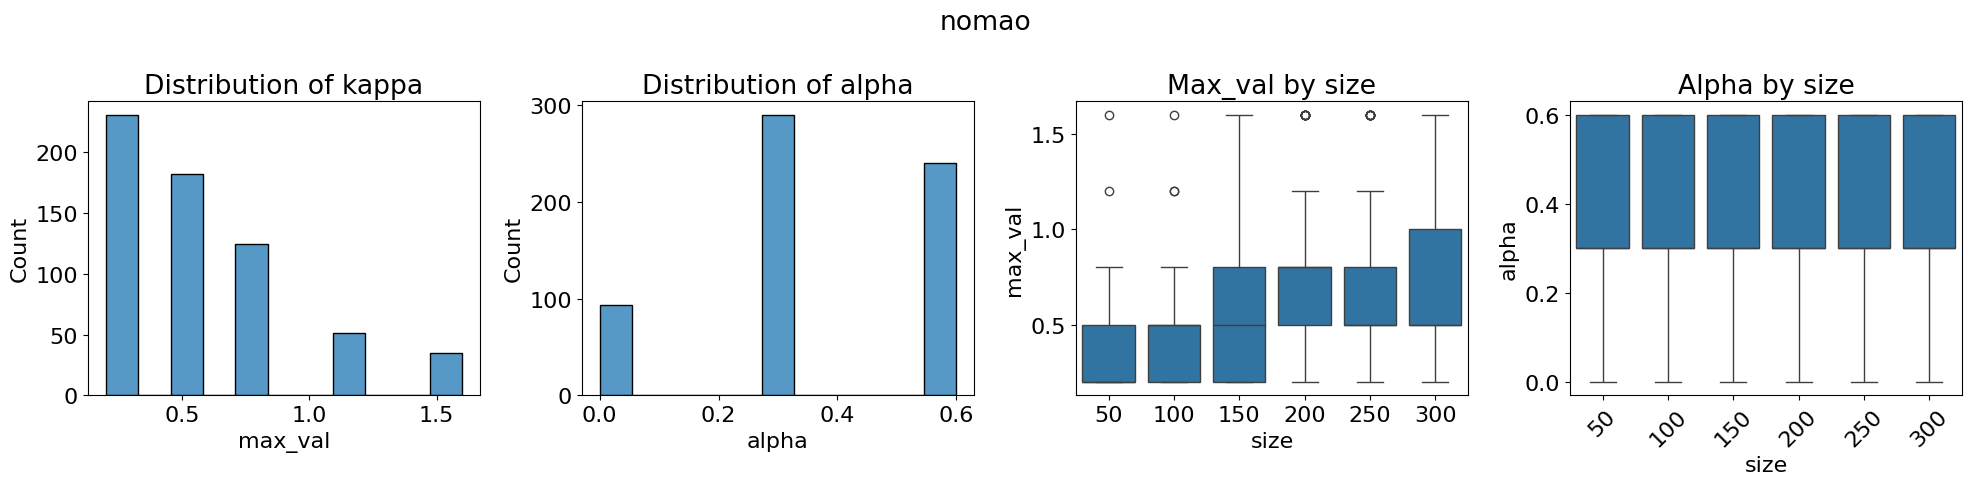

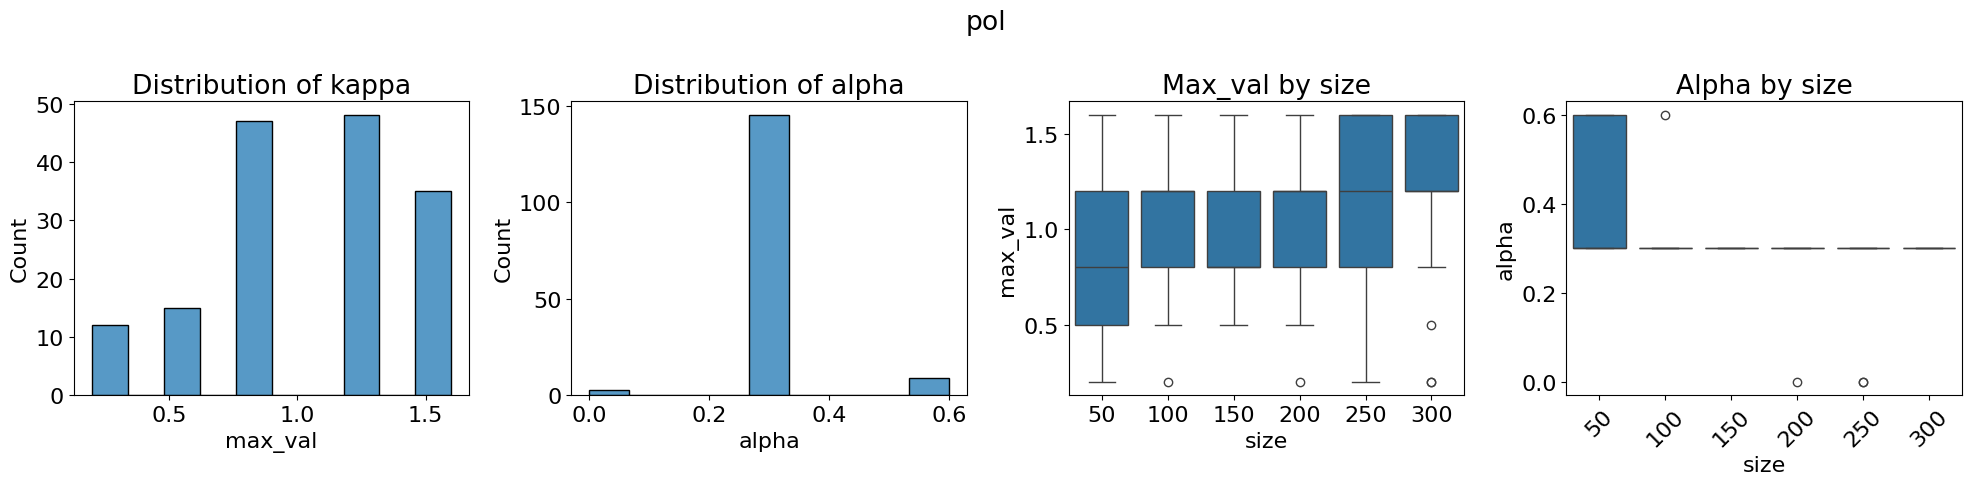

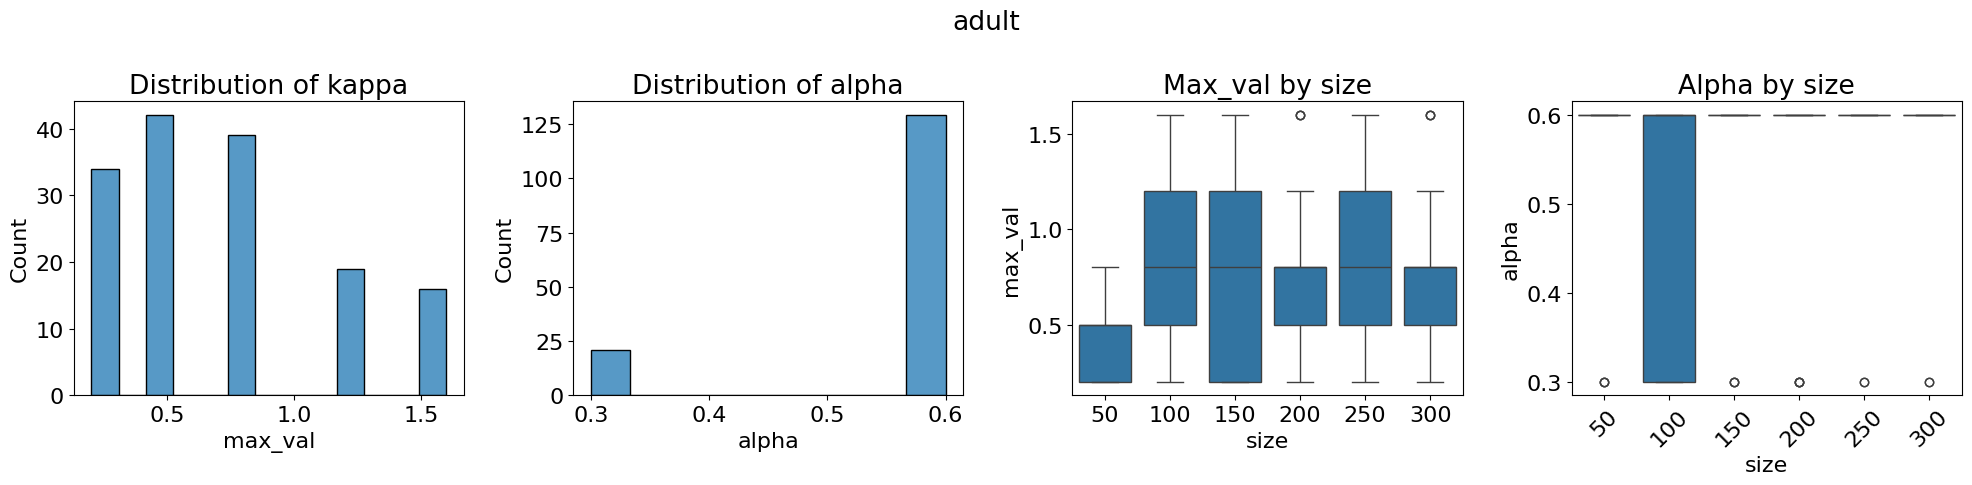

In [6]:
plot_stats_for_dataset("cifar10-embeddings")
plot_stats_for_dataset("imdb-embeddings")
plot_stats_for_dataset("bbc-embeddings")
plot_stats_for_dataset("nomao")
plot_stats_for_dataset("pol")
plot_stats_for_dataset("adult")